# Homework Starter — Stage 10a: Linear Regression

Use this as a scaffold if your project data isn’t ready. Replace the synthetic data section with your dataset when possible.

In [1]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install scipy
# !pip install pandas
# !pip install seaborn
# !pip install matplotlib
# !pip install scikit-learn

In [2]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.model_selection import train_test_split
import scipy.stats as st

sns.set()
np.random.seed(7)

Matplotlib is building the font cache; this may take a moment.


## 1) Synthetic data (replace with your project data when ready)
- Finance-flavored factors and asset excess return
- Includes a quadratic effect to motivate specification checks

In [3]:
n = 200
dates = pd.bdate_range(start="2024-02-01", periods=n)
mkt_excess = np.random.normal(0, 0.011, size=n)
size = np.random.normal(0, 0.008, size=n)
value = np.random.normal(0, 0.009, size=n)
momentum = np.random.normal(0, 0.006, size=n)

beta0, beta_mkt, beta_size, beta_value, beta_mom, beta_mom2 = 0.0001, 0.9, 0.25, -0.15, 0.35, 3.5
noise_scale = 0.0035 + 0.5*np.abs(mkt_excess)
eps = np.random.normal(0, noise_scale)
asset_excess = (
    beta0 + beta_mkt*mkt_excess + beta_size*size + beta_value*value + beta_mom*momentum
    + beta_mom2*(momentum**2) + eps
)
df = pd.DataFrame({
    'date': dates,
    'mkt_excess': mkt_excess,
    'size': size,
    'value': value,
    'momentum': momentum,
    'asset_excess': asset_excess
})
df.head()

,date,mkt_excess,size,value,momentum,asset_excess
0,2024-02-01,0.018596,-0.013467,-0.000540,0.000141,0.014832
1,2024-02-02,-0.005125,0.008120,0.007089,-0.006840,-0.008599
2,2024-02-05,0.000361,-0.011532,-0.012885,-0.011216,-0.009577
3,2024-02-06,0.004483,-0.010749,0.003905,-0.010685,0.000033
4,2024-02-07,-0.008678,-0.002893,0.001250,0.002779,-0.005750


## 2) Baseline model fit
Follow the steps; replace `df` with your project DataFrame when ready.

In [4]:
X = df[['mkt_excess','size','value','momentum']]
y = df['asset_excess']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
lr = LinearRegression().fit(X_train, y_train)
y_pred = lr.predict(X_test)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f'Baseline   R²={r2:.4f}  RMSE={rmse:.6f}')

Baseline   R²=0.3677  RMSE=0.008470


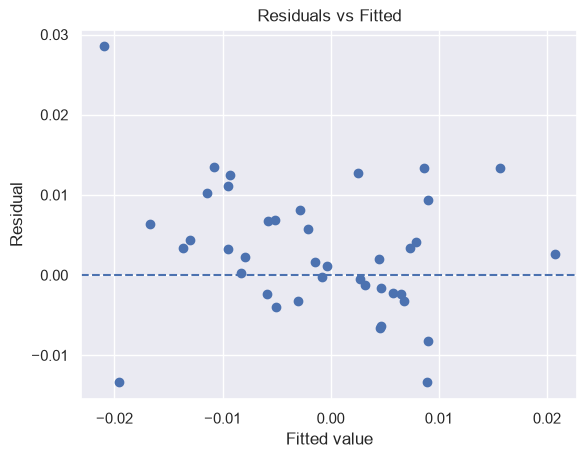

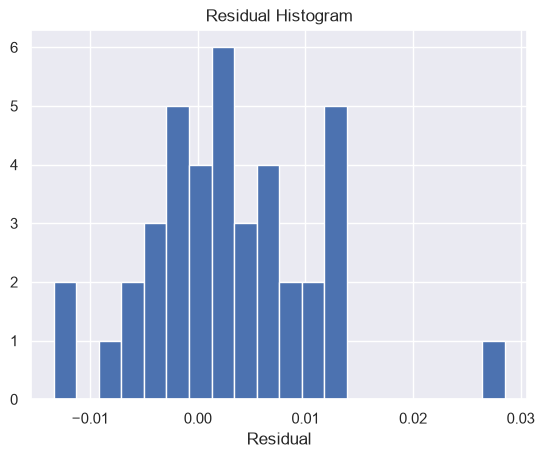

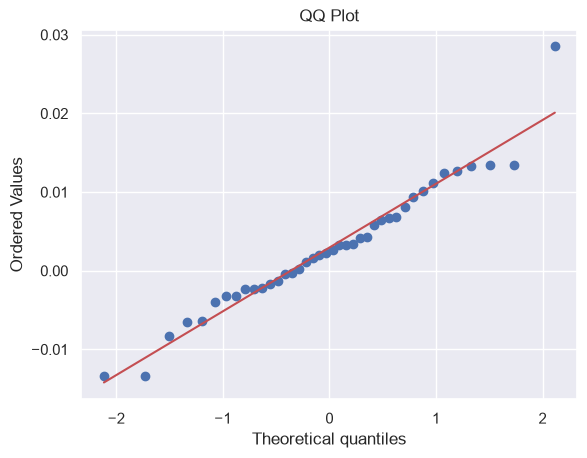

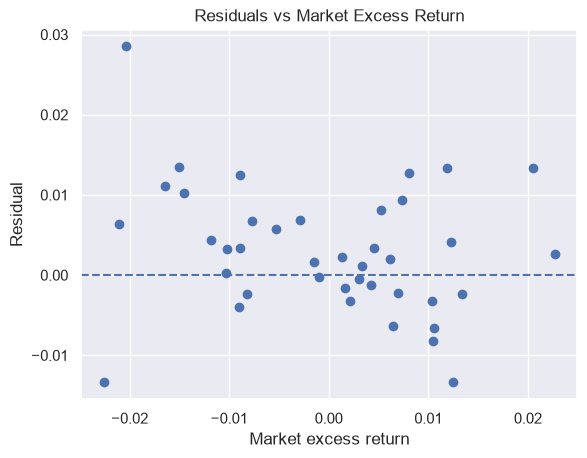

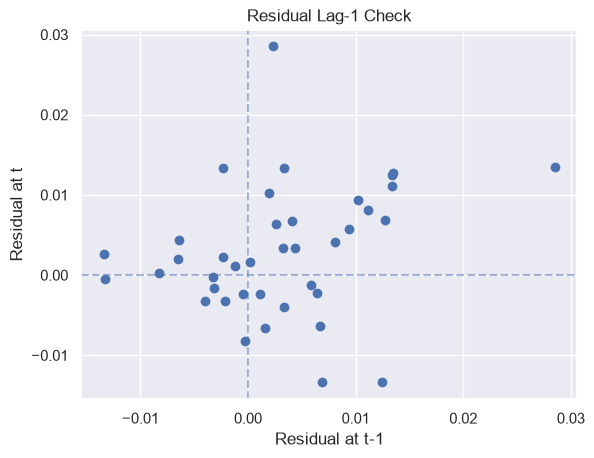

In [5]:
resid = y_test - y_pred
fitted = y_pred

plt.figure()
plt.scatter(fitted, resid)
plt.axhline(0, ls='--')
plt.title('Residuals vs Fitted')
plt.xlabel('Fitted value')
plt.ylabel('Residual')
plt.show()

plt.figure()
plt.hist(resid, bins=20)
plt.title('Residual Histogram')
plt.xlabel('Residual')
plt.show()

plt.figure()
st.probplot(resid, dist='norm', plot=plt)
plt.title('QQ Plot')
plt.show()

plt.figure()
plt.scatter(X_test['mkt_excess'], resid)
plt.axhline(0, ls='--')
plt.title('Residuals vs Market Excess Return')
plt.xlabel('Market excess return')
plt.ylabel('Residual')
plt.show()

plt.figure()
plt.scatter(resid.iloc[:-1], resid.iloc[1:])
plt.axhline(0, ls='--', alpha=0.5)
plt.axvline(0, ls='--', alpha=0.5)
plt.title('Residual Lag-1 Check')
plt.xlabel('Residual at t-1')
plt.ylabel('Residual at t')
plt.show()


## 3) Optional: Add a transformed feature
Add a polynomial or interaction if diagnostics suggest mis-specification.

In [6]:
df['momentum_sq'] = df['momentum']**2
X2 = df[['mkt_excess','size','value','momentum','momentum_sq']]
X2_train, X2_test = X2.iloc[:len(X_train)], X2.iloc[len(X_train):]
lr2 = LinearRegression().fit(X2_train, y_train)
y_pred2 = lr2.predict(X2_test)
r2_2 = r2_score(y_test, y_pred2)
rmse_2 = np.sqrt(mean_squared_error(y_test, y_pred2))
print(f'With x^2   R²={r2_2:.4f}  RMSE={rmse_2:.6f}')

With x^2   R²=0.3681  RMSE=0.008467


## 4) Interpretation

- **Linearity:** The residuals are centered near zero, but the starter data include a quadratic momentum effect that the baseline model omits. Adding `momentum_sq` is therefore a justified specification check.
- **Homoscedasticity:** Residual spread tends to increase when market excess returns are more extreme because the data generator uses market-dependent noise. Constant variance is therefore imperfect.
- **Normality:** The histogram and QQ plot are broadly centered but tail departures are possible; inference that assumes perfectly Gaussian residuals should be treated cautiously.
- **Independence:** The lag-1 residual plot does not show a strong systematic pattern, but a single holdout period is not enough to rule out time dependence.
- **Model trust:** I trust the transformed model more when it improves holdout R-squared and RMSE because it represents the known nonlinear momentum effect while remaining linear in its coefficients. Trust is still limited by heteroscedasticity and synthetic data.
- **Next step:** Test robust standard errors and rolling time-series validation, then compare the transformed model with a simple market-only baseline.
